In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Car Sale.csv")

In [3]:
df.head(1)

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown


In [4]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [6]:
df.isnull().sum()

Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


Q1 What is the average selling price of cars for each dealer, and how does it compare across different dealers?

In [8]:
df['Price ($)'].mean()

28090.247845729107

In [9]:
avg_price_per_dealer = df.groupby('Dealer_Name')['Price ($)'].mean().sort_values(ascending= False)

In [10]:
avg_price_per_dealer

Dealer_Name
U-Haul CO                                          28769.919006
Classic Chevy                                      28602.014446
Rabun Used Car Sales                               28527.536177
Iceberg Rentals                                    28522.958533
Enterprise Rent A Car                              28312.580800
Scrivener Performance Engineering                  28297.371589
Gartner Buick Hyundai Saab                         28247.621019
Saab-Belle Dodge                                   28190.139888
Capitol KIA                                        28189.703822
Race Car Help                                      28163.372706
Chrysler of Tri-Cities                             28123.091054
Star Enterprises Inc                               28113.055244
Suburban Ford                                      28112.206758
C & M Motors Inc                                   28111.755200
Tri-State Mack Inc                                 28095.562050
Pars Auto Sales             

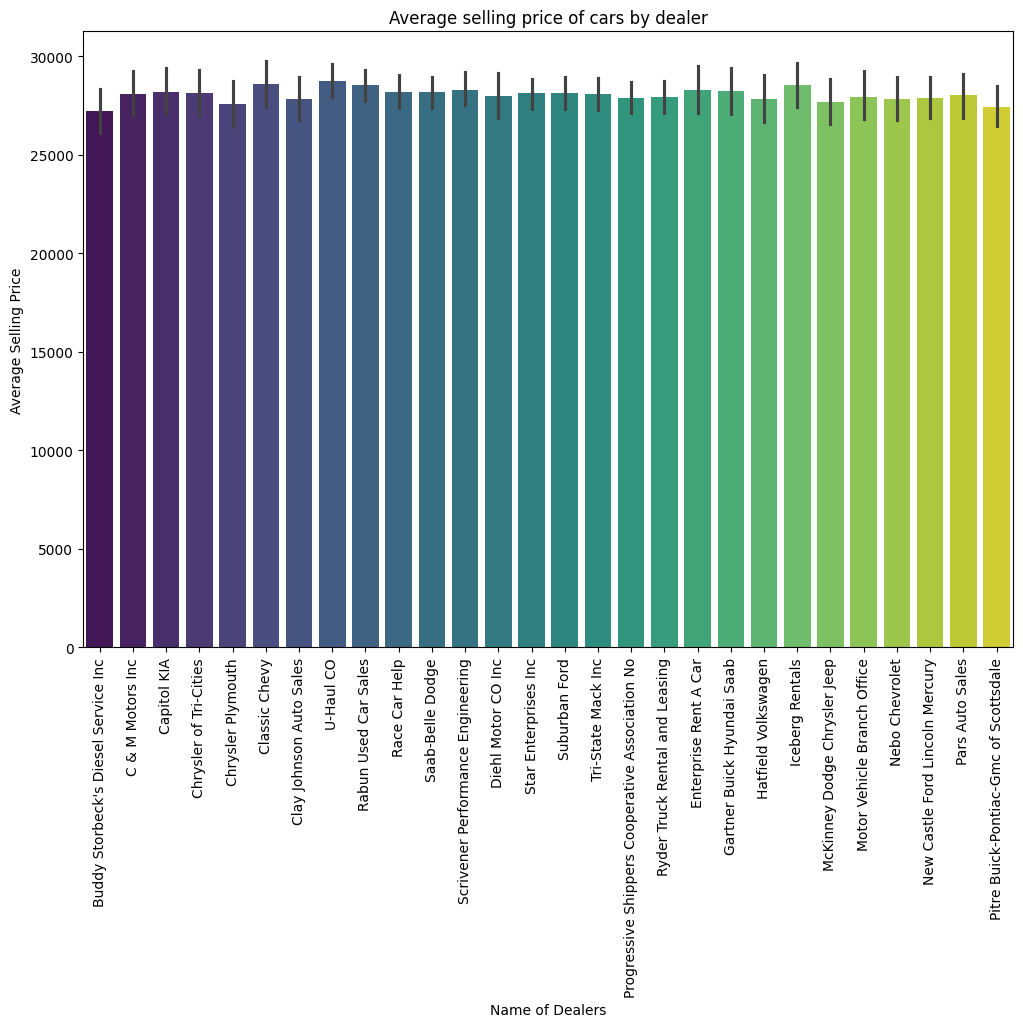

In [11]:
plt.figure(figsize= (12, 8))
sns.barplot(x='Dealer_Name', y='Price ($)', data=df, palette= 'viridis')
plt.xlabel('Name of Dealers')
plt.xticks(rotation = 90)
plt.ylabel('Average Selling Price')
plt.title("Average selling price of cars by dealer")

plt.show()

Q2 Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?

In [12]:
# Which car brand (Company) has the highest variation in prices?"

# Har company ka price variation (standard deviation) nikalna hai.
# Jis company ka standard deviation zyada hoga, uska price variation bhi zyada hoga.

In [13]:
# "What does this tell us about the pricing trends?"

# Agar ek brand ka price variation zyada hai, iska matlab ho sakta hai:
# Us brand ki low-end aur high-end dono range ki cars available hain.
# Different models, conditions (new/used), and features ke wajah se price gap bada hai.
# Agar variation kam hai, iska matlab zyadatar cars ek hi price range me bik rahi hain.

# idxmax() ka use sabse bada value jis index pe hai, uska naam return karne ke liye hota hai.



In [14]:
price_variation =  df.groupby('Company')['Price ($)'].std().sort_values(ascending= False)
high_variation_brand = price_variation.idxmax()
high_variation_value = price_variation.max()

In [15]:
price_variation

Company
Lincoln       19658.050211
Saab          19653.740089
Cadillac      19517.120220
Plymouth      19065.997338
Lexus         17852.923492
Buick         17142.232626
Mercury       16445.172195
Nissan        16214.264017
Saturn        15990.223671
Ford          15849.090227
Mercedes-B    15722.807459
Oldsmobile    15711.345857
Toyota        15367.131714
BMW           15065.578723
Pontiac       14348.963592
Infiniti      13696.332844
Chevrolet     13311.063223
Volvo         12933.790185
Subaru        12920.771620
Audi          12904.243867
Volkswagen    12527.124011
Mitsubishi    11671.343035
Chrysler      11583.286811
Dodge         11187.592085
Honda         11148.629062
Jaguar        10222.531533
Jeep           9459.834418
Acura          8183.046414
Porsche        5261.839206
Hyundai        3485.982649
Name: Price ($), dtype: float64

In [16]:
high_variation_brand

'Lincoln'

In [17]:
high_variation_value

19658.050211265567

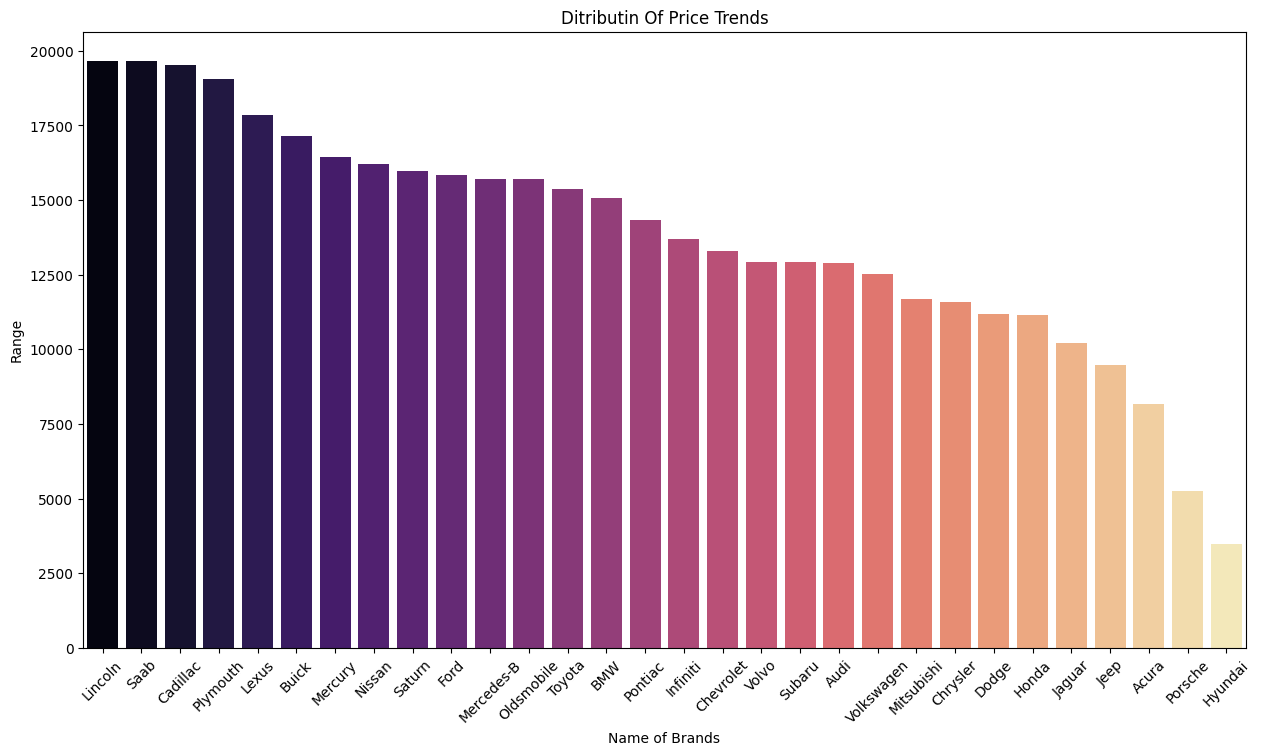

In [18]:
plt.figure(figsize=(15, 8))
sns.barplot(x= price_variation.index, y= price_variation.values,palette= 'magma')
plt.xticks(rotation = 45)
plt.xlabel('Name of Brands')
plt.ylabel('Range')
plt.title("Ditributin Of Price Trends")

plt.show()

In [19]:
# Insights>> Lincoln brand ki car ka SDevia zada hai as compare to Hyundai, it means This Lincoln brand has highest variation in price

In [20]:
# Nothing, I just using different features

# plt.figure(figsize=(15, 8))
# sns.barplot(x= "Company", y= "Price ($)", data = df, palette= 'magma')
# plt.xticks(rotation = 45)
# plt.xlabel('Name of Brands')
# plt.ylabel('Range')
# plt.title("Ditributin Of Price Trends")

Q3 What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?

In [21]:
# Ques Breakdown:-
# Manual and automatic cars k selling_price ka distribution dekhna h
# Visaulize with histogram 

# How to do Interquartile Range (IQR) compare?
# formula: IQR = Q3-Q1

In [22]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [23]:
df.Transmission.unique()

array(['Auto', 'Manual'], dtype=object)

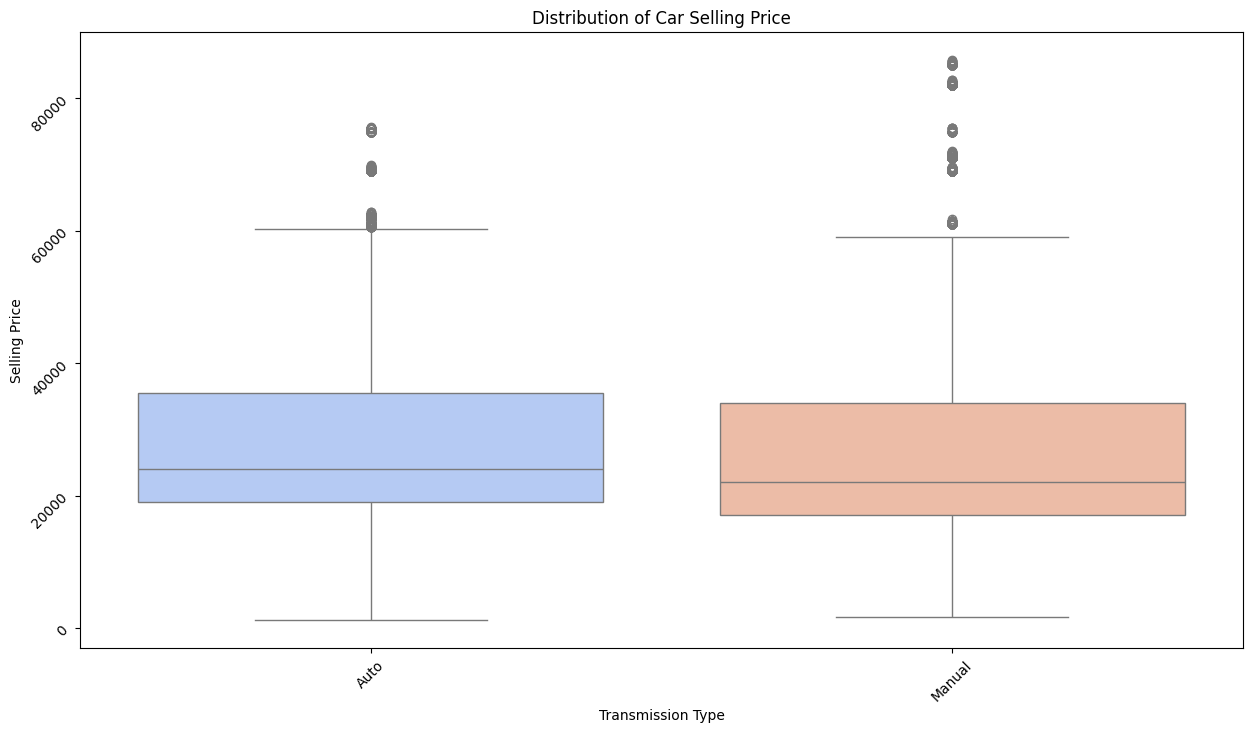

In [24]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Transmission', y= 'Price ($)', data=df, palette="coolwarm")
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.title("Distribution of Car Selling Price")
plt.show()

Q4 What is the distribution of car prices across different regions?

In [25]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

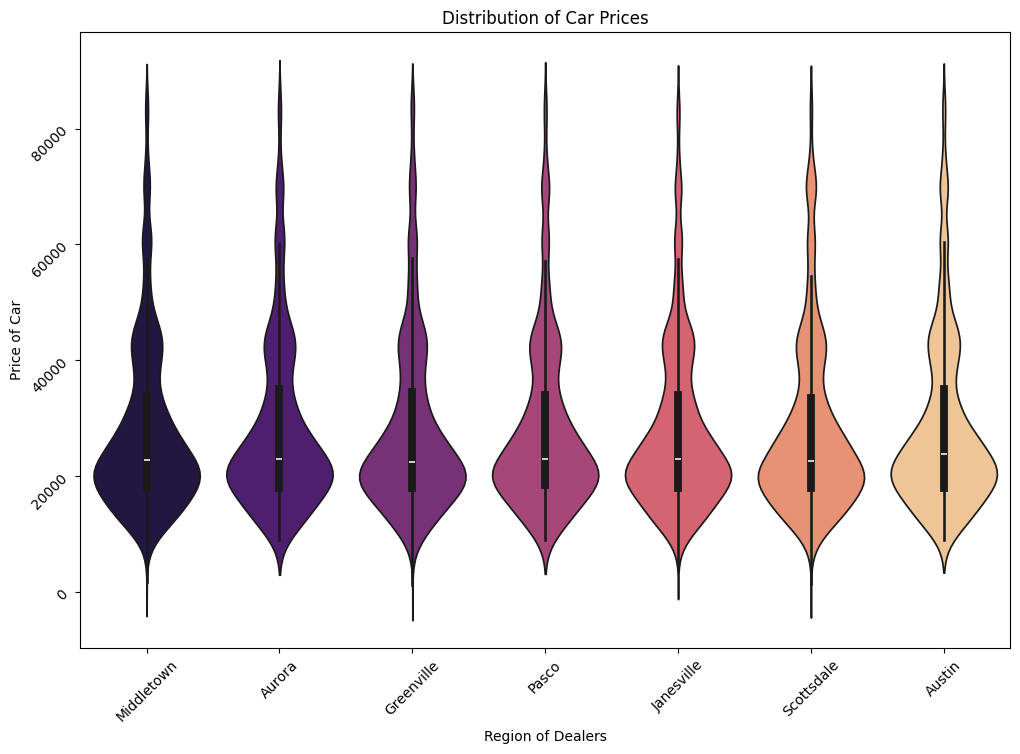

In [26]:
# In Barplot
plt.figure(figsize=(12, 8))
sns.violinplot(x='Dealer_Region', y= 'Price ($)', data = df, palette = 'magma')
plt.xlabel("Region of Dealers")
plt.ylabel('Price of Car')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.title("Distribution of Car Prices")

plt.show()

In [27]:
# In Histogram

#  KDE (Kernel Density Estimate) Ka Matlab
# 👉 KDE ek smooth curve hota hai jo data ka distribution dikhata hai.
# 👉 Yeh histogram ka ek advanced version hai jo estimate karta hai ki data kis range me zyada concentrated hai.

# plt.figure(figsize=(12, 8))
# sns.histplot(x= "Dealer_Region", hue= "Price ($)", data = df, bins= 30, kde=True, palette = "tab10")
# plt.xlabel("Region of Dealers")
# plt.ylabel('Price of Car')
# plt.xticks(rotation = 45)
# plt.yticks(rotation = 45)
# plt.title("Distribution of Car Prices")

# plt.show()

Q5 What is the distribution of cars based on body styles?

In [28]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

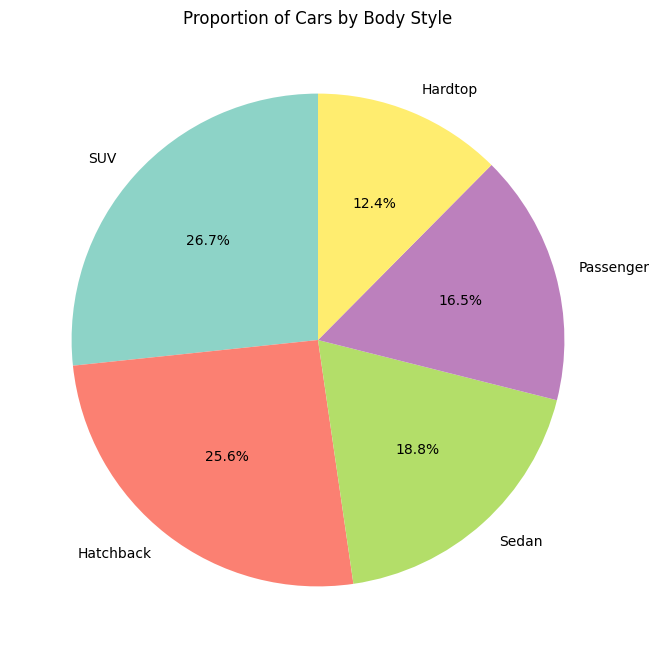

In [29]:
# Using pie chart (Best for Proportion Analysis)

plt.figure(figsize= (8,8))
df['Body Style'].value_counts().plot.pie(autopct= "%1.1f%%", cmap= "Set3", startangle = 90)
plt.ylabel("") #Extra label hatane k liye
plt.title("Proportion of Cars by Body Style")

plt.show()

Q5 How does the average selling price of cars vary by customer gender and annual income?

In [30]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [31]:
# NOT WORKING PROPERLY*

# plt.figure(figsize= (15,8))
# sns.boxplot(x = 'Gender', y= 'Price ($)', hue='Annual Income', data = df, palette= 'pastel')
# plt.xlabel('Customer Gender')
# plt.ylabel('Average Selling Price')
# plt.title("Distribution of Car Prices by Gender and Annual Income")
# plt.legend(title = "Annual Income")

# plt.show()

Q7 What is the distribution of car prices by region, and how does the number of cars sold vary by region?

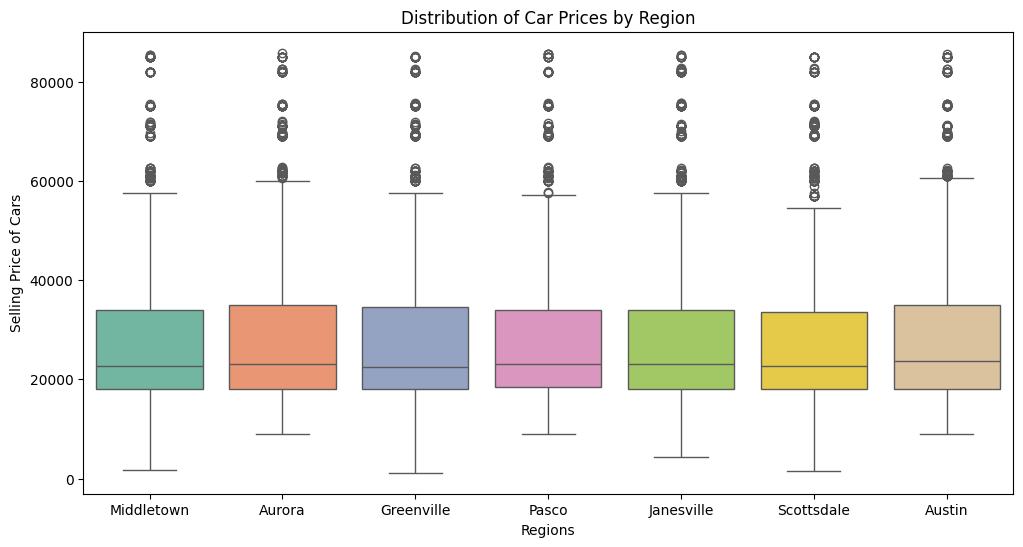

In [32]:
# Car prices ka distribution har region me kaisa hai?

# Price Distribution Across Regions with Boxplot
plt.figure(figsize= (12, 6))
sns.boxplot(x= 'Dealer_Region',y='Price ($)',  data=df, palette= 'Set2')
plt.xlabel("Regions")
plt.ylabel('Selling Price of Cars')
plt.title("Distribution of Car Prices by Region")

plt.show()

In [33]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

Why not uses "y=" function because X-axis pe unique categories (e.g., regions) rakhta hai aur Y-axis pe unka count automatically calculate kar leta hai.

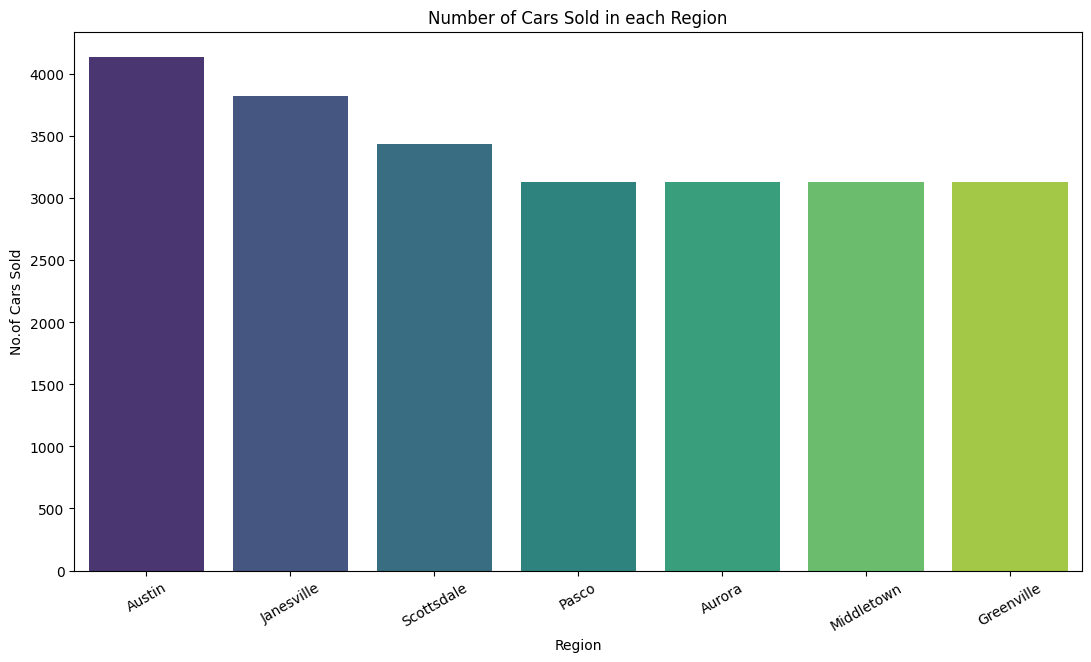

In [34]:
# Har region me kitni cars bik rahi hain?

# Number of Cars Sold in Each Region with Barplot

plt.figure(figsize= (13, 7))
sns.countplot(x='Dealer_Region', data=df, palette='viridis', order=df['Dealer_Region'].value_counts().index)
plt.xticks(rotation = 30)
plt.xlabel('Region')
plt.ylabel('No.of Cars Sold')
plt.title('Number of Cars Sold in each Region')

plt.show()

In [35]:
# Insights>> Highest no of cars are sold in Austin region

Q8 How does the average car price differ between cars with different engine sizes?

In [36]:
df['Price ($)'].mean()

28090.247845729107

In [37]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

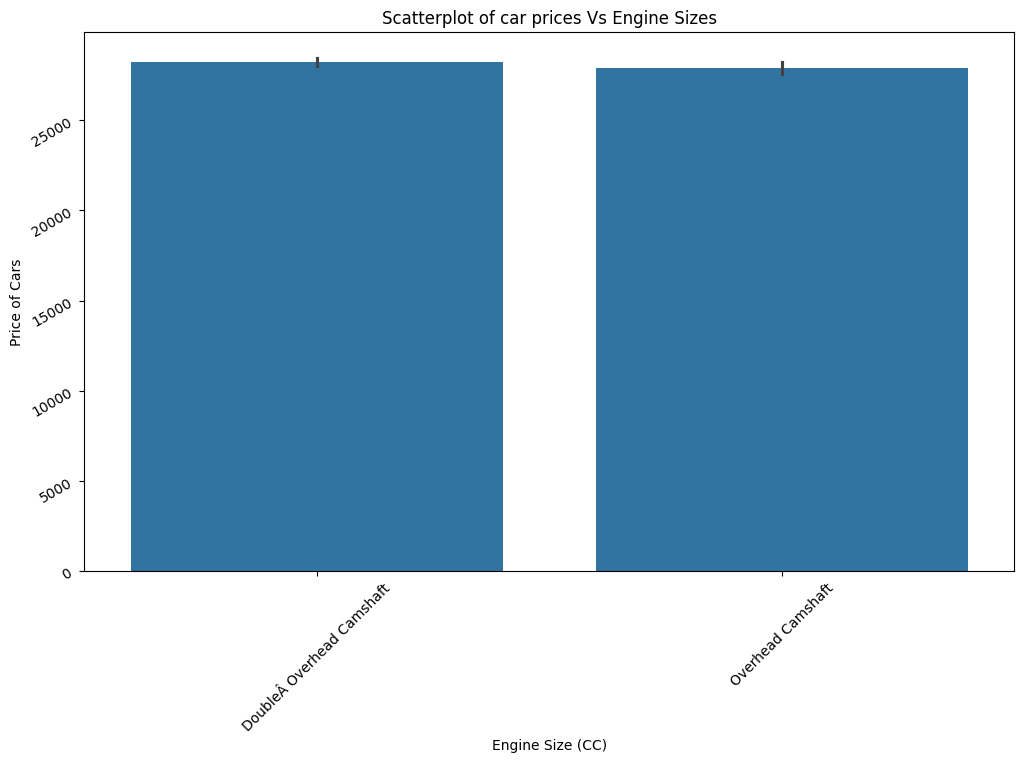

In [38]:
plt.figure(figsize= (12, 7))
sns.barplot(x='Engine', y = 'Price ($)', data=df)
plt.xlabel('Engine Size (CC)')
plt.xticks(rotation = 45)
plt.ylabel('Price of Cars')
plt.yticks(rotation = 30)
plt.title("Scatterplot of car prices Vs Engine Sizes")

plt.show()

Q9 How do car prices vary based on the customer's annual income bracket?

In [39]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

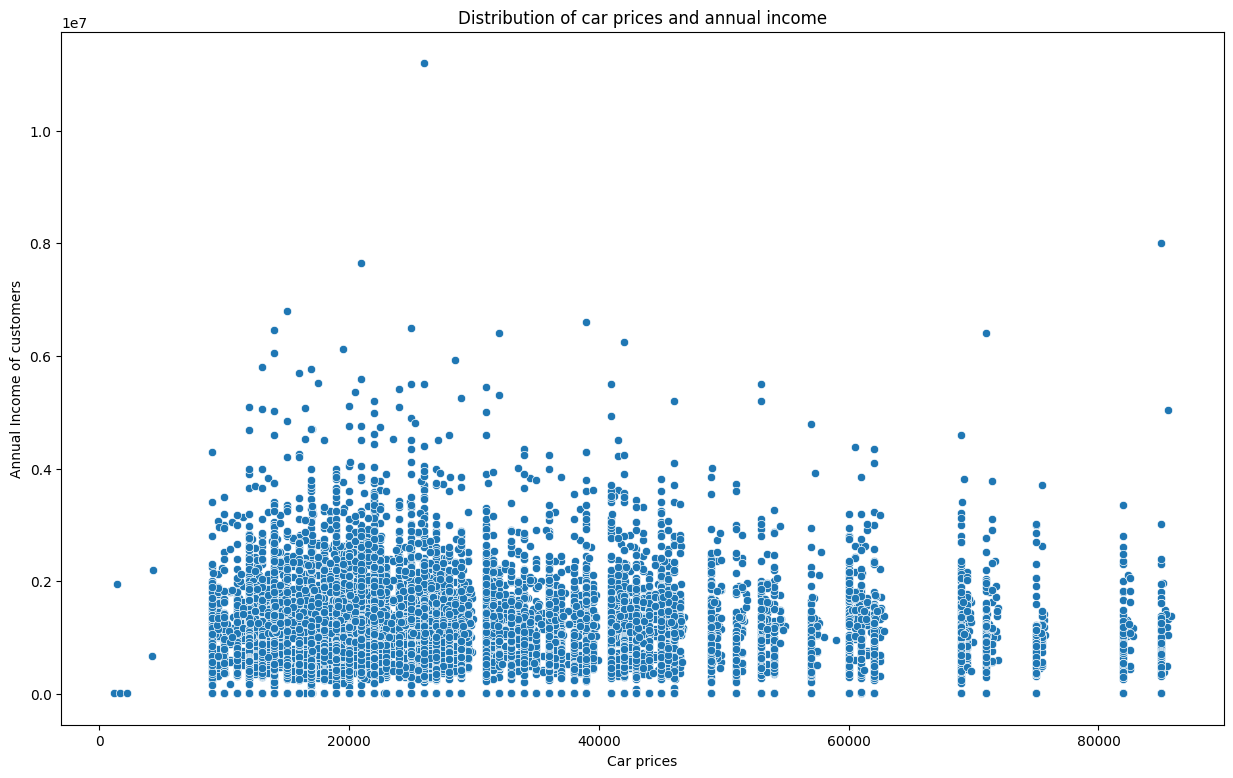

In [40]:
plt.figure(figsize=(15,9))
sns.scatterplot(x= 'Price ($)', y= 'Annual Income', data=df, palette= "magma")
plt.xlabel('Car prices')
plt.ylabel('Annual Income of customers')
plt.title("Distribution of car prices and annual income")

plt.show()

Q10 What are the top 5 car models with the highest number of sales, and how does their price distribution look?

In [41]:
top_5_car = df['Company'].value_counts().head(5).index

In [42]:
top_5_car

Index(['Chevrolet', 'Dodge', 'Ford', 'Volkswagen', 'Mercedes-B'], dtype='object', name='Company')

In [43]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [44]:
df.head(5)

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


Q10 What are the top 5 car models with the highest number of sales, and how does their price distribution look?

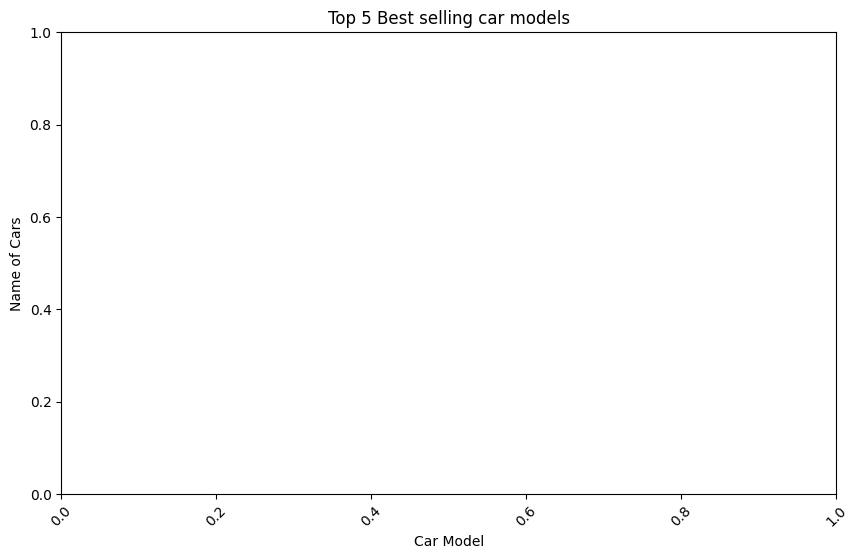

In [45]:
# Visulization by barplot (countplot:- Counts the occurrences of categories)
plt.figure(figsize= (10, 6))
sns.countplot(x="Model", data=df[df['Model'].isin(top_5_car)], order=top_5_car, palette="magma")
plt.xlabel('Car Model')
plt.ylabel('Name of Cars')
plt.title('Top 5 Best selling car models')
plt.xticks(rotation = 45)

plt.show()

Q11 How does car price vary with engine size across different car colors, and which colors have the highest price variation?

In [46]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [47]:
# plt.figure(figsize=(12, 6))
# sns.lmplot(x="Engine", y="Price ($)", hue="Color", data=df, aspect=1.5, scatter_kws={'alpha':0.5})
# plt.xlabel("Engine Size (cc)")
# plt.ylabel("Selling Price")
# plt.title("Car Price Variation with Engine Size Across Colors")
# plt.show()

# # Calculating price variation for each color
# price_variation = df.groupby("Color")["Price ($)"].std().sort_values(ascending=False)
# print(price_variation.head()) 

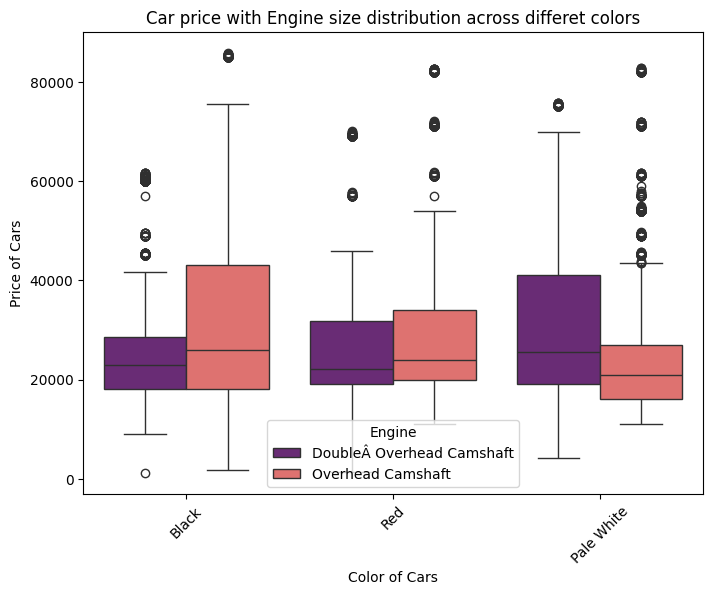

In [48]:
plt.figure(figsize= (8, 6))
sns.boxplot(x = 'Color', y = 'Price ($)', hue= 'Engine', data=df, palette= 'magma')
plt.xlabel('Color of Cars')
plt.ylabel("Price of Cars")
plt.title('Car price with Engine size distribution across differet colors')
plt.xticks(rotation = 45)

plt.show()

Q12 Is there any seasonal trend in car sales based on the date of sale?

In [49]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [50]:
df["Date"]

0          1/2/2022
1          1/2/2022
2          1/2/2022
3          1/2/2022
4          1/2/2022
            ...    
23901    12/31/2023
23902    12/31/2023
23903    12/31/2023
23904    12/31/2023
23905    12/31/2023
Name: Date, Length: 23906, dtype: object

In [51]:
# converting 'date_of_sale' to datetime formate if not already
df['Date'] = pd.to_datetime(df['Date'])

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month

monthly_sale = df.groupby('month').size()

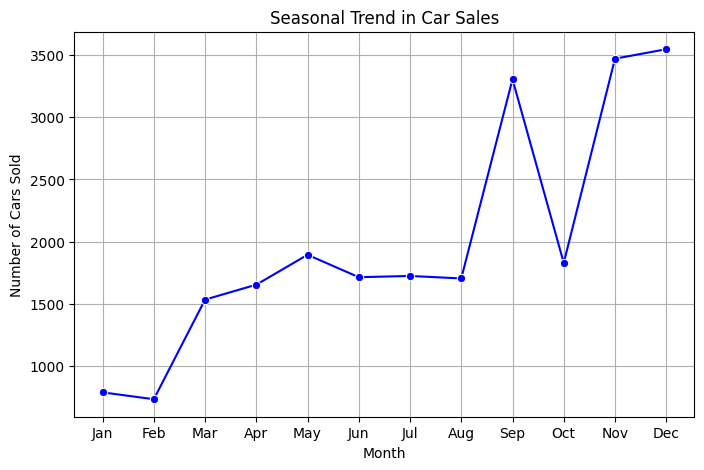

In [52]:
plt.figure(figsize= (8,5))
sns.lineplot(x=monthly_sale.index, y=monthly_sale.values, marker='o', color = 'b')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Month')
plt.ylabel('Number of Cars Sold')
plt.title('Seasonal Trend in Car Sales')
plt.grid(True)
plt.show()

In [53]:
# Insights >> Higest sale in month of between November to December